## Object Detection
Naive approach to object detection:
- Break image into tiles
- Run CNN image classified through each time
- Select tiles with activation above the threshold

In [10]:
import cv2
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os

os.environ["HTTP_PROXY"] = "http://127.0.0.1:3128"
os.environ["HTTPS_PROXY"] = "http://127.0.0.1:3128"

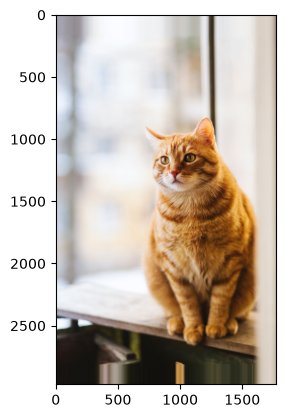

In [11]:
img = cv2.imread('data/cat.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = np.pad(img, ((158, 158), (0, 0), (0, 0)), mode = 'edge')
plt.imshow(img)

In [ ]:
vgg = keras.applications.vgg16.VGG16(weights=None)
vgg.load_weights("weight/vgg16_weights_tf_dim_ordering_tf_kernels.h5")

In [15]:
def predict(img):
    im = cv2.resize(img, (224, 224))
    im = keras.applications.vgg16.preprocess_input(im)
    pr = vgg.predict(np.expand_dims(im, axis = 0))[0]

    return np.sum(pr[281:294])

predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step


np.float32(0.7531742)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12

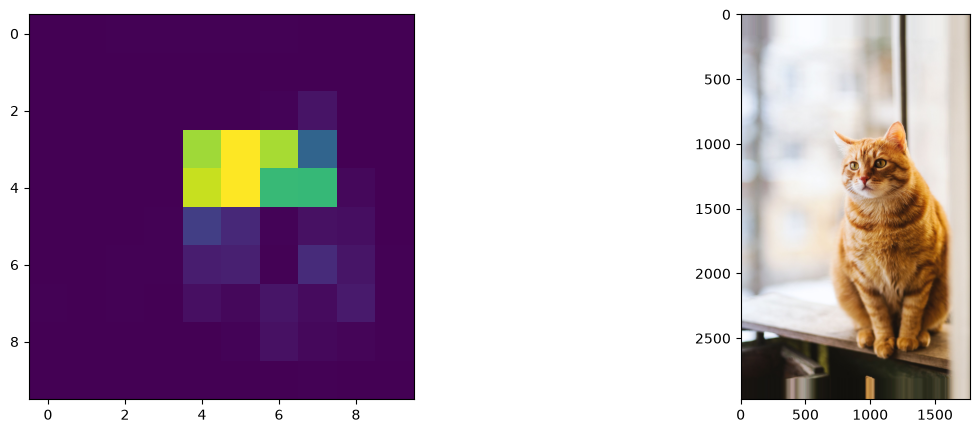

In [19]:
def predict_map(img, n):
    # Calculate step sizes for height and width independently
    dh = img.shape[0] // n
    dw = img.shape[1] // n
    res = np.zeros((n, n), dtype=np.float32)

    for i in range(n):
        for j in range(n):
            im = img[dh * i : dh * (i + 1), dw * j : dw * (j + 1)]
            
            if im.size == 0:
                continue
                
            r = predict(im)
            res[i, j] = r

    return res

fig, ax = plt.subplots(1, 2, figsize = (15, 5))
ax[1].imshow(img)
ax[0].imshow(predict_map(img, 10))

### Detecting Simple Objects
To give more precise location of a bounding box, we need to run regression model to predict bounding box coordinates. Let's start with simple example of having black rectangles in 32x32 images, which we want to detect.

In [20]:
def generate_images(num_imgs, img_size = 8, min_object_size = 1, max_object_size = 4):
    bboxes = np.zeros((num_imgs, 4))
    imgs = np.zeros((num_imgs, img_size, img_size))

    for i in range(num_imgs):
        w, h = np.random.randint(min_object_size, max_object_size, size = 2)
        x = np.random.randint(0, img_size - w)
        y = np.random.randint(0, img_size - h)
        imgs[i, x:x + w, y:y + h] = 1
        bboxes[i] = [x, y, w, h]
    
    return imgs, bboxes

imgs, bboxes = generate_images(100000)
print(f"Images shape = {imgs.shape}")
print(f"BBoxes shape = {bboxes.shape}")

Images shape = (100000, 8, 8)
BBoxes shape = (100000, 4)


In [21]:
bb = bboxes / 8.0
bb[0]

array([0.375, 0.25 , 0.375, 0.125])

In [22]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape = (8, 8)),
    keras.layers.Dense(200, activation = 'relu'),
    keras.layers.Dropout(0.2), 
    keras.layers.Dense(4)
])

model.compile('sgd', 'mse')
model.summary()

c:\Users\DLA7HC\practise-framework\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │        13,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           804 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,804 (53.92 KB)

 Trainable params: 13,804 (53.92 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
imgs_norm = (imgs - np.mean(imgs)) / np.std(imgs)
model.fit(imgs_norm, bb, epochs = 30)

Epoch 1/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0573
Epoch 2/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 961us/step - loss: 0.0128
Epoch 3/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 851us/step - loss: 0.0075
Epoch 4/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 841us/step - loss: 0.0058
Epoch 5/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 932us/step - loss: 0.0050
Epoch 6/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 889us/step - loss: 0.0045
Epoch 7/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 869us/step - loss: 0.0042
Epoch 8/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 866us/step - loss: 0.0039
Epoch 9/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 835us/step - loss: 0.0037
Epoch 10/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 845us/step - loss: 0.0036
Epoch 11/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 953us/step - loss: 0.0034
Epoch 12/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step - loss: 0.0033
Epoch 13/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 863us/step - loss: 0.0032
Epoch 14/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 910us/step - loss: 0.0031
Epo

In [24]:
def IOU(bb1, bb2):
    x1, y1, w1, h1 = bb1
    x2, y2, w2, h2 = bb2

    w_I = min(x1 + w1, x2 + w2) - max(x1, x2)
    h_I = min(y1 + h1, y2 + h2) - max(y1, y2)

    if w_I <= 0 or h_I <= 0:
        return 0
    
    I = w_I * h_I
    U = w1 * h1 + w2 * h2 - I

    return I / U

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
pred=[2.0400186 4.869068  2.1938007 1.9228203],act=[2. 5. 2. 2.], IOU=0.7462613286989015
pred=[5.112487  2.0186222 1.0784053 2.6466916],act=[5. 2. 1. 3.], IOU=0.6701334640060145
pred=[3.0168447 1.9067551 1.9958239 2.9083757],act=[3. 2. 2. 3.], IOU=0.8973083902694904
pred=[0.17867708 2.1152973  2.6483474  1.2194121 ],act=[0. 2. 3. 1.], IOU=0.6028673974513928
pred=[-0.11865163  3.941402    2.040014    2.1057923 ],act=[0. 4. 2. 2.], IOU=0.8629284136242579


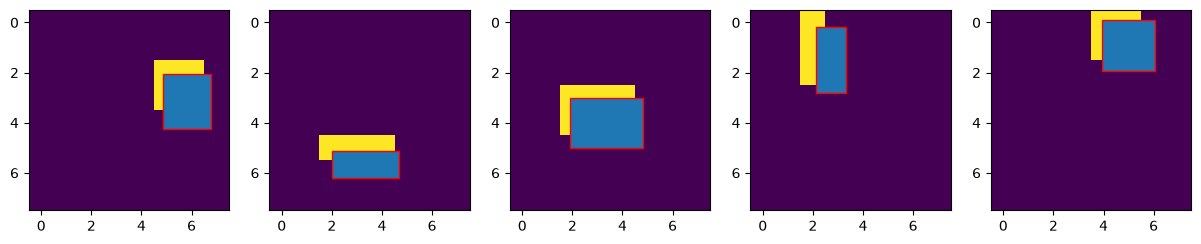

In [25]:
import matplotlib

test_imgs, test_bboxes = generate_images(500)
bb_res = model.predict((test_imgs-np.mean(imgs))/np.std(imgs))*8

plt.figure(figsize=(15,5))
for i in range(5):
    print(f"pred={bb_res[i]},act={test_bboxes[i]}, IOU={IOU(bb_res[i],test_bboxes[i])}")
    plt.subplot(1,5,i+1)
    plt.imshow(test_imgs[i])
    plt.gca().add_patch(matplotlib.patches.Rectangle((bb_res[i,1],bb_res[i,0]),bb_res[i,3],bb_res[i,2],ec='r'))

In [26]:
np.array([IOU(a, b) for a, b in zip(test_bboxes, bb_res)]).mean()

np.float64(0.6915560149266469)